[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sunilmogadati/systems-in-production/blob/main/implementation/notebooks/Step2_Logistic_Regression.ipynb)

# Step 2: Logistic Regression — From Numbers to Decisions

**For:** AI (Artificial Intelligence) Engineer Accelerator — Cohort 01  
**Instructor:** Sunil Mogadati

**What we'll cover today:**
- The shift from regression (predicting numbers) to classification (predicting yes/no)
- The sigmoid function: how to convert any number into a probability (0 to 1)
- The four types of outcomes and why they're NOT all equal
- Confusion matrix: seeing ALL your mistakes, not just "accuracy"
- Precision vs Recall: the tradeoff that changes everything
- The threshold: your most powerful knob for tuning the model
- ROC (Receiver Operating Characteristic — a curve showing model quality)/AUC (Area Under the Curve — single score for model quality): comparing models without picking a threshold
- Cross-validation: avoiding lucky/unlucky data splits
- How to interpret what the model actually learned (feature importance)

## Glossary — Abbreviations Used in This Notebook

Keep this handy. Every abbreviation is explained when first used, but here's your quick reference:

| Abbreviation | Full Form | Plain English |
|-------------|-----------|---------------|
| **ML** | Machine Learning | Teaching computers to learn from data |
| **TP** | True Positive | Model said YES, and it was actually YES (correct!) |
| **TN** | True Negative | Model said NO, and it was actually NO (correct!) |
| **FP** | False Positive | Model said YES, but it was actually NO (false alarm) |
| **FN** | False Negative | Model said NO, but it was actually YES (missed it!) |
| **ROC** | Receiver Operating Characteristic | A curve showing model quality at all thresholds |
| **AUC** | Area Under the Curve | Single number summarizing the ROC curve (0.5 = random, 1.0 = perfect) |
| **MSE** | Mean Squared Error | Average of squared mistakes (from Step 1 — regression metric) |
| **F1** | F1 Score | Harmonic mean of Precision and Recall — one number balancing both |
| **CV** | Cross-Validation | Testing a model on multiple data splits to get reliable scores |
| **NLP** | Natural Language Processing | Teaching computers to understand human language |
| **RAG** | Retrieval-Augmented Generation | Connecting an AI model to your own documents for Q&A |
| **LLM** | Large Language Model | AI models like ChatGPT, Claude — trained on massive text data |
| **std** | Standard Deviation | How spread out numbers are from the average |
| **FPR** | False Positive Rate | Percentage of actual negatives that were wrongly flagged as positive |
| **TPR** | True Positive Rate | Same as Recall — percentage of actual positives that were caught |

#### Math Symbols Used in This Notebook

| Symbol | How to Read It | What It Means |
|--------|---------------|---------------|
| **σ(z)** | "sigma of z" | The sigmoid function: `1 / (1 + e⁻ᶻ)` — converts any number to a probability (0 to 1) |
| **e** | "e" or "Euler's number" | The constant 2.71828... — base of natural logarithm |
| **e⁻ᶻ** | "e to the negative z" | e raised to the power of negative z |
| **log** | "log" or "natural log" | Logarithm — the inverse of exponentiation. `log(e²) = 2` |
| **ŷ** | "y-hat" | The model's predicted probability |
| **Σ** | "the sum of" | Add up all values |
| **≥** | "greater than or equal to" | `P ≥ 0.5` = "probability greater than or equal to 0.5" → predict yes |
| **·** | "times" or "dot" | Multiplication: `w₁·income` = "w-sub-1 times income" |
| **₁, ₂, ₃** | "sub 1, sub 2, sub 3" | Subscript index: `w₁` = "w sub 1" = the first weight |
| **∂L/∂w** | "dee L dee w" or "partial of L with respect to w" | How much the loss changes when you adjust weight w |
| **AI** | Artificial Intelligence |

## Part 1: The Concept (No Code Yet)

### What is Logistic Regression in plain English?

Despite the name, Logistic Regression is a **classification** algorithm.
It predicts the **probability** that something belongs to a category.

**Example:** A bank wants to predict whether a loan applicant will default.
- Input: income, debt, credit score, employment years
- Output: probability of default (e.g., 0.73 = 73% chance of default)
- Decision: if probability > 0.5 → predict "will default" → reject loan

### How does it work?

1. Start with Linear Regression: `z = w₁·income + w₂·debt + w₃·credit + b`
2. Problem: `z` can be any number (-∞ to +∞). We need a probability (0 to 1).
3. Solution: Push `z` through the **sigmoid function**: `p = 1 / (1 + e^(-z))`

The sigmoid squashes any number into the range (0, 1). That's the whole trick.

**Software analogy:** Linear Regression gives you a raw score. Sigmoid is like
a normalizer that converts any raw score into a percentage. Think of it like
converting a test score to a percentile rank.

### The Critical Addition: The Threshold

The model outputs a probability (e.g., 0.73). But you need a YES or NO.
So you pick a **threshold** — typically 0.5:
- probability ≥ 0.5 → predict "yes" (positive class)
- probability < 0.5 → predict "no" (negative class)

**This threshold is where ALL the interesting problems in classification come from.**
Change the threshold, and you change which mistakes your model makes.

## Architect's Decision Checklist — Classification Edition

The same 7 questions from Step 1, but now the answers change because we're predicting **categories** instead of numbers.

| Decision | Question | Logistic Regression's Answer |
|:---------|:---------|:----------------------------|
| **Problem Type** | Number or category? | Category (binary classification) |
| **Class Balance** | Are the classes evenly split? | Often no → use stratified split |
| **Metric** | What metric matches the business goal? | Precision (avoid false alarms) vs Recall (catch all positives) |
| **Threshold** | Is the default 0.5 cutoff appropriate? | Rarely → tune based on cost of false positives vs false negatives |
| **Baseline** | What's the "do nothing" performance? | Always predict majority class (e.g., 87% "no churn") |
| **Evaluation** | Single number to report? | AUC (threshold-independent), or F1 (threshold-dependent) |
| **Interpretability** | Need to explain decisions? | Yes → log-odds coefficients show feature impact |

> **New concern:** In classification, **which type of mistake is worse?** Missing a churning customer (false negative) or flagging a happy customer (false positive)? This decision drives your metric choice, threshold, and how you present results to the business.


## Part 2: The Hello World

In [1]:
# ============================================================
# ============================================================
# 
# The probability is the KEY DIFFERENCE from regression.
# In Step 1, we predicted a NUMBER ($350K). Now we predict a
# PROBABILITY (e.g., 73% chance of passing).

import numpy as np
from sklearn.linear_model import LogisticRegression

# This follows the EXACT same pattern as Step 1 (Linear Regression).
# The only difference: y is now 0 or 1 (binary classes), not a continuous number.
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = np.array([  0,   0,   0,   0,   1,   0,   1,   1,   1,   1 ])

# LogisticRegression() works almost identically to LinearRegression():
#   - .fit(X, y) learns from the data
#   - But internally, it uses a different loss function (Log Loss, not MSE)
#   - And it fits a SIGMOID CURVE (S-shaped), not a straight line
model = LogisticRegression()
model.fit(X, y)

# This is where Logistic Regression differs from Linear Regression.
# .predict_proba(X) returns PROBABILITIES for both classes.
#   [prob_fail, prob_pass] — these sum to 1.0
# .predict(X) applies the 0.5 threshold to give a hard yes/no.
prob = model.predict_proba([[5.5]])[0]      # All probabilities for this one sample
prediction = model.predict([[5.5]])[0]      # The hard decision (0 or 1)

print(f"Student who studied 5.5 hours:")
print(f"  Probability of failing: {prob[0]:.1%}")
print(f"  Probability of passing: {prob[1]:.1%}")
print(f"  Decision (using 0.5 threshold): {'PASS' if prediction == 1 else 'FAIL'}")
print(f"")
print(f"KEY INSIGHT: The model outputs a PROBABILITY, not a decision.")
print(f"You can then CHOOSE your threshold (default is 0.5).")
print(f"Change the threshold, and you change which mistakes you make.")
print(f"This is where all the interesting ML happens.")

Student who studied 5.5 hours:
  Probability of failing: 50.0%
  Probability of passing: 50.0%
  Decision (using 0.5 threshold): FAIL

KEY INSIGHT: The model outputs a PROBABILITY, not a decision.
You can then CHOOSE your threshold (default is 0.5).
Change the threshold, and you change which mistakes you make.
This is where all the interesting ML happens.


### What Just Happened?

1. The model found a line (just like Linear Regression)
2. It pushed that line through the sigmoid to get probabilities
3. `.predict_proba()` gives you the raw probability
4. `.predict()` applies the 0.5 threshold to give you a yes/no

Let's visualize the sigmoid — this is the core of Logistic Regression:

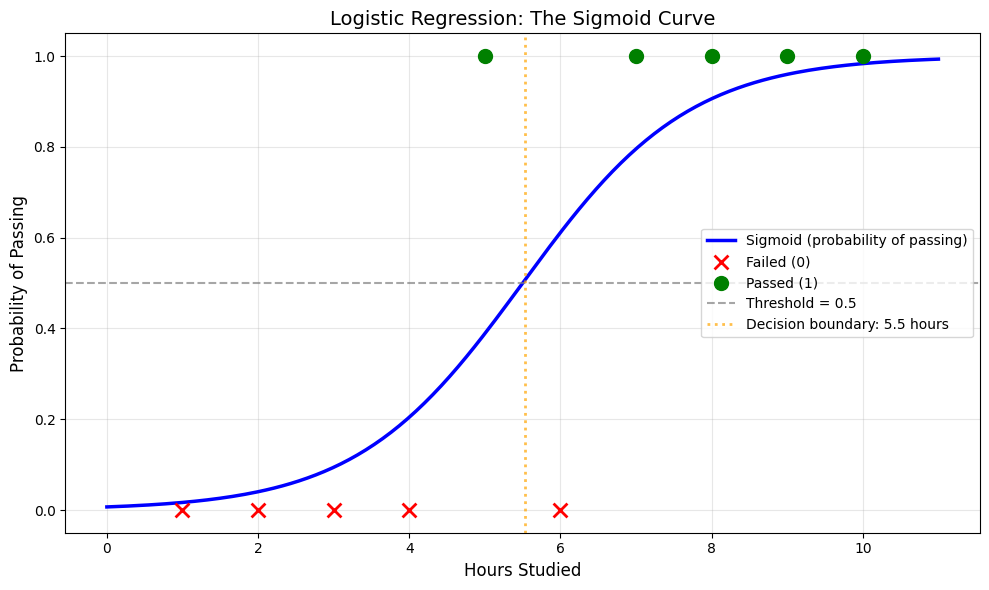

THE SIGMOID CURVE:
  This S-shape converts study hours into probabilities.
  At ~5.5 hours, the model is 50/50 on passing.

KEY OBSERVATIONS:
  1. The student at 6 hours actually FAILED (red X on the curve).
     This shows the real world is messy — patterns aren't perfect.
     The model can't achieve 100% accuracy because the data is noisy.

  2. The curve is STEEPEST in the middle (around 5-6 hours).
     This is where predictions change most rapidly.
     At the edges (very low/high hours), changes matter less.

  3. The curve NEVER goes below 0 or above 1 (unlike a line).
     This is why sigmoid is essential — probabilities MUST be between 0 and 1.

CLASS DISCUSSION QUESTION:
  'How would you change the decision boundary to catch MORE students
   who are about to fail, even if it means more false alarms?'


In [2]:
# ============================================================
# VISUALIZE THE SIGMOID — The core of Logistic Regression
# ============================================================
# 
# The curve is called a SIGMOID (S-shaped). This S-shape is what makes
# Logistic Regression different from Linear Regression.
# 
# Why an S-shape? Because:
#   - At 0 hours, probability of passing ≈ 0 (makes sense)
#   - At 10 hours, probability ≈ 100% (makes sense)
#   - In the middle, it transitions smoothly (which captures real behavior)
# A straight line would give negative probabilities at low hours — impossible!

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

X_range = np.linspace(0, 11, 200).reshape(-1, 1)
probs = model.predict_proba(X_range)[:, 1]  # [prob_fail, prob_pass] — we want index 1

# This curve is the MODEL'S UNDERSTANDING of the relationship between
# study hours and probability of passing.
plt.plot(X_range, probs, color='blue', linewidth=2.5, label='Sigmoid (probability of passing)')

# Red X's = students who failed
# Green dots = students who passed
# The model's job is to position the curve so it separates these two groups.
plt.scatter(X[y==0], y[y==0], color='red', s=100, zorder=5, label='Failed (0)', 
            marker='x', linewidths=2)
plt.scatter(X[y==1], y[y==1], color='green', s=100, zorder=5, label='Passed (1)', 
            marker='o')

# This is the "decision boundary" for predictions.
# If probability >= 0.5 → predict pass
# If probability < 0.5 → predict fail
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Threshold = 0.5')

# This is the EXACT study hours where the model is 50/50 on passing.
# Below this → fail, above this → pass (roughly)
decision_boundary = X_range[np.argmin(np.abs(probs - 0.5))][0]
plt.axvline(x=decision_boundary, color='orange', linestyle=':', alpha=0.7, linewidth=2,
            label=f'Decision boundary: {decision_boundary:.1f} hours')

plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Probability of Passing', fontsize=12)
plt.title('Logistic Regression: The Sigmoid Curve', fontsize=14)
plt.legend(fontsize=10, loc='center right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"THE SIGMOID CURVE:")
print(f"  This S-shape converts study hours into probabilities.")
print(f"  At ~{decision_boundary:.1f} hours, the model is 50/50 on passing.")
print(f"")
print(f"KEY OBSERVATIONS:")
print(f"  1. The student at 6 hours actually FAILED (red X on the curve).")
print(f"     This shows the real world is messy — patterns aren't perfect.")
print(f"     The model can't achieve 100% accuracy because the data is noisy.")
print(f"")
print(f"  2. The curve is STEEPEST in the middle (around 5-6 hours).")
print(f"     This is where predictions change most rapidly.")
print(f"     At the edges (very low/high hours), changes matter less.")
print(f"")
print(f"  3. The curve NEVER goes below 0 or above 1 (unlike a line).")
print(f"     This is why sigmoid is essential — probabilities MUST be between 0 and 1.")
print(f"")
print(f"CLASS DISCUSSION QUESTION:")
print(f"  'How would you change the decision boundary to catch MORE students")
print(f"   who are about to fail, even if it means more false alarms?'")

## Part 3: The Four Types of Outcomes

This is **the most important concept in classification.** Everything else
(precision, recall, F1, ROC (Receiver Operating Characteristic — a curve showing model quality)) is built on these four outcomes.

When your model makes a prediction, exactly ONE of four things happens:

```
                        ACTUAL
                   Positive    Negative
              ┌────────────┬────────────┐
  PREDICTED   │    TRUE    │   FALSE    │
  Positive    │  POSITIVE  │  POSITIVE  │
              │   (TP) ✅   │   (FP) ❌   │
              ├────────────┼────────────┤
  PREDICTED   │   FALSE    │    TRUE    │
  Negative    │  NEGATIVE  │  NEGATIVE  │
              │   (FN) ❌   │   (TN) ✅   │
              └────────────┴────────────┘
```

**The naming convention:** The first word (True/False) tells you if the model
was RIGHT or WRONG. The second word (Positive/Negative) tells you what the
model PREDICTED.

### Real-World Example: Cancer Screening

| Outcome | What Happened | How Bad Is It? |
|---------|--------------|----------------|
| **True Positive** | Patient has cancer, test says cancer | ✅ Correct — gets treatment |
| **True Negative** | Patient is healthy, test says healthy | ✅ Correct — no unnecessary worry |
| **False Positive** | Patient is healthy, test says cancer | ⚠️ Scary but catchable — more tests will clarify |
| **False Negative** | Patient has cancer, test says healthy | 💀 **DEADLY** — patient goes home untreated |

**The key insight:** Not all mistakes are equal. A False Negative (missed cancer)
is FAR worse than a False Positive (false alarm). This is why accuracy alone
is a terrible metric — it treats all mistakes equally.

## Part 4: A Real Classification Problem

Let's build a more realistic example: predicting whether a customer will **churn**
(cancel their subscription). This is a classic business ML problem.

In [3]:
# ============================================================
# ============================================================
# The "Hello World" example was useful, but now let's do something REALISTIC.
# We're going to predict whether a customer will churn (cancel subscription).
# 
# This is one of the TOP use cases for classification in the real world.
# Why? Because if you can predict who will leave, you can reach out and
# save them before they go. That customer is worth $$$, so ML (Machine Learning) ROI (Return on Investment) is huge.
# 
# We'll generate synthetic data that mimics a real telecom company's metrics.
# It has 2,000 customers and follows realistic churn patterns.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

np.random.seed(42)
n = 2000  # 2,000 customer records


tenure_months = np.random.exponential(24, n).clip(1, 72)
# INTERPRETATION: How long has this person been a customer (in months)?
# Exponential distribution = more new customers than old (realistic).
# Clipped to [1, 72] = between 1 month and 6 years.

monthly_charge = np.random.normal(65, 25, n).clip(20, 120)
# INTERPRETATION: How much does this customer pay monthly (in $)?
# Normal distribution around $65, ranging $20-$120.

support_calls = np.random.poisson(1.5, n)
# INTERPRETATION: How many support tickets did they open?
# Poisson = count data. Higher = more problems = more churn risk.

usage_hours = np.random.exponential(30, n).clip(1, 200)
# INTERPRETATION: How many hours/month do they use the product?
# Exponential with clipping. High usage = satisfied customer = low churn risk.

contract_type = np.random.choice([0, 1, 2], n, p=[0.5, 0.3, 0.2])
# INTERPRETATION: Contract length (0=month-to-month, 1=annual, 2=2-year).
# Longer contracts = less likely to churn (locked in).

# This is the "signal" the model will try to learn.
# In real life, you have historical data. Here we create it synthetically.
churn_score = (
    -0.04 * tenure_months        # longer tenure → LESS churn (negative coefficient)
    + 0.02 * monthly_charge      # higher bill → MORE churn (positive coefficient)
    + 0.3 * support_calls        # more support calls → MORE churn (they're frustrated)
    - 0.01 * usage_hours          # more usage → LESS churn (they love the product)
    - 0.8 * contract_type         # longer contract → LESS churn
    + np.random.normal(0, 0.8, n) # add randomness (real data is noisy)
)

# This is exactly what logistic regression will learn to do.
churn_prob = 1 / (1 + np.exp(-churn_score))

# If random number < churn_prob, mark as churned
churned = (np.random.random(n) < churn_prob).astype(int)

df = pd.DataFrame({
    'tenure_months': tenure_months,
    'monthly_charge': monthly_charge,
    'support_calls': support_calls,
    'usage_hours': usage_hours,
    'contract_type': contract_type,
    'churned': churned
})

print(f"Dataset: {len(df)} customers")
print(f"Churned: {churned.sum()} ({churned.mean():.1%})")
print(f"Stayed:  {(1-churned).sum()} ({1-churned.mean():.1%})")
print(f"")
print(f"First 10 customers:")
print(df.head(10).to_string(index=False))
print(f"")
print(f"CLASS IMBALANCE OBSERVATION:")
print(f"  {churned.mean():.1%} churned, {1-churned.mean():.1%} stayed")
print(f"  This is close to 50/50 (balanced) in this synthetic data.")
print(f"  Real-world churn rates are often 5-20% (very imbalanced).")
print(f"  This imbalance is WHY accuracy is a trap metric.")
print(f"  A 'dumb' model that predicts 'no churn' for everyone gets 80-95% accuracy!")
print(f"")
print(f"INTERVIEW QUESTION:")
print(f"  'Why is accuracy useless for imbalanced datasets?'")
print(f"ANSWER:")
print(f"  'A model that predicts the majority class (no churn) every time")
print(f"   gets high accuracy but catches ZERO actual churners.'")

Dataset: 2000 customers
Churned: 955 (47.8%)
Stayed:  1045 (52.2%)

First 10 customers:
 tenure_months  monthly_charge  support_calls  usage_hours  contract_type  churned
     11.262434       43.050435              2    14.145185              1        0
     72.000000       44.327991              0    22.963328              0        0
     31.601897       59.338028              1    62.769268              0        1
     21.910621       74.184138              1    73.078371              0        0
      4.070997       87.839616              2     9.276328              2        1
      4.070311       44.920526              1    18.604736              2        0
      1.436130      102.317214              2    23.898219              0        1
     48.269541       58.221910              2    89.344114              0        0
     22.057972       64.465818              0   197.511931              0        0
     29.550001       46.319708              4     8.052358              1        0

In [4]:
# ============================================================
# ============================================================
# Reminder: We learned in Step 1 that you MUST:
#   1. Split the data FIRST (train 80%, test 20%)
#   2. Fit the scaler on training data ONLY
#   3. Transform test data using the scaler learned from training
# 
# Why? To prevent DATA LEAKAGE — the test set must be invisible to the
# learning process, including the scaling process.

X_all = df[['tenure_months', 'monthly_charge', 'support_calls', 'usage_hours', 'contract_type']].values
y_all = df['churned'].values

# stratify=y_all is CRUCIAL for imbalanced classification.
# Without it, you might randomly assign 70% of churners to test and 30% to train.
# The scaler (and model) would learn on a different distribution than it's tested on.
# stratify ensures BOTH train and test have the same churn rate as the overall dataset.
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

scaler = StandardScaler()

# Fit AND transform on training data (learn the mean/std (standard deviation) from training)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data ONLY (apply the SAME scaling, don't learn from test)
X_test_scaled = scaler.transform(X_test)

print(f"Data split complete:")
print(f"  Training: {len(X_train)} customers ({y_train.mean():.1%} churned)")
print(f"  Test:     {len(X_test)} customers ({y_test.mean():.1%} churned)")
print(f"")
print(f"Churn rates match because stratify=y_all ensures balanced split.")
print(f"")
print(f"SCALING DETAILS:")
print(f"  Original tenure_months range: [{tenure_months.min():.1f}, {tenure_months.max():.1f}]")
print(f"  After scaling, mean=0 and std (standard deviation) = 1 (across all five features)")
print(f"  This puts all features on equal footing.")
print(f"")
print(f"GOLDEN RULE (from Step 1, repeated because it's critical):")
print(f"  .fit_transform() on TRAINING data  (learn AND apply scaling)")
print(f"  .transform()     on TEST data      (apply SAME scaling, don't learn)")

Data split complete:
  Training: 1600 customers (47.8% churned)
  Test:     400 customers (47.8% churned)

Churn rates match because stratify=y_all ensures balanced split.

SCALING DETAILS:
  Original tenure_months range: [1.0, 72.0]
  After scaling, mean=0 and std=1 (across all five features)
  This puts all features on equal footing.

GOLDEN RULE (from Step 1, repeated because it's critical):
  .fit_transform() on TRAINING data  (learn AND apply scaling)
  .transform()     on TEST data      (apply SAME scaling, don't learn)


In [5]:
# ============================================================
# ============================================================
# Now we train a Logistic Regression model on 1,600 customers.
# Then we predict on 400 new customers it has never seen.
# 
# We'll output the first 10 predictions so you can see:
#   - What the customer actually did (Actual)
#   - What the model predicted (Predicted)
#   - How confident the model was (Prob(Churn))
#   - Did it get it right? (Correct?)

model_churn = LogisticRegression(random_state=42)
model_churn.fit(X_train_scaled, y_train)

# .predict_proba(X) returns a 2D array: [[prob_stayed, prob_churned], ...]
#   We extract the second column (index 1) to get prob of churn
# .predict(X) applies the 0.5 threshold to return 0 or 1
y_pred = model_churn.predict(X_test_scaled)                    # Hard predictions: 0 or 1
y_prob = model_churn.predict_proba(X_test_scaled)[:, 1]        # Probabilities: 0.0 to 1.0

print(f"First 10 predictions on test data:")
print(f"{'Actual':>8} {'Predicted':>10} {'Prob(Churn)':>12} {'Correct?':>10}")
print("-" * 45)
for i in range(10):
    correct = '✅' if y_test[i] == y_pred[i] else '❌'
    print(f"{y_test[i]:>8} {y_pred[i]:>10} {y_prob[i]:>12.1%} {correct:>10}")

print(f"")
print(f"HOW TO READ THIS:")
print(f"  Actual = what really happened (1=churned, 0=stayed)")
print(f"  Predicted = what model says (0.5 threshold applied)")
print(f"  Prob(Churn) = confidence in churn prediction (higher=more certain)")
print(f"  Correct = did model match reality?")
print(f"")
print(f"NOTICE: A customer with Prob(Churn)=50.4% was classified as '1' (churn)")
print(f"  because 50.4% >= 0.5. But they ACTUALLY STAYED (actual=0).")
print(f"  This is a FALSE POSITIVE — a mistake. (We'll count these soon.)")
print(f"")
print(f"KEY INSIGHT:")
print(f"  The model outputs a PROBABILITY for every customer.")
print(f"  That probability is the MOST USEFUL output.")
print(f"  The hard 0/1 decision (using 0.5 threshold) is just a convenience.")
print(f"  Next, we'll learn how to optimize the threshold for business value.")

First 10 predictions on test data:
  Actual  Predicted  Prob(Churn)   Correct?
---------------------------------------------
       1          1        60.9%          ✅
       0          0        47.5%          ✅
       0          0        13.1%          ✅
       0          1        50.4%          ❌
       1          1        79.5%          ✅
       0          0        34.2%          ✅
       0          0        39.7%          ✅
       1          1        67.4%          ✅
       0          1        74.6%          ❌
       1          0        32.4%          ❌

HOW TO READ THIS:
  Actual = what really happened (1=churned, 0=stayed)
  Predicted = what model says (0.5 threshold applied)
  Prob(Churn) = confidence in churn prediction (higher=more certain)
  Correct = did model match reality?

NOTICE: A customer with Prob(Churn)=50.4% was classified as '1' (churn)
  because 50.4% >= 0.5. But they ACTUALLY STAYED (actual=0).
  This is a FALSE POSITIVE — a mistake. (We'll count these soon.)

K

## Part 5: The Accuracy Trap

Let's start with the metric everyone knows — and show why it's dangerous.

In [6]:
# ============================================================
# THE ACCURACY TRAP — Why a single metric can destroy your project
# ============================================================
# Everyone knows accuracy: (# correct) / (# total)
# 
# It's also USELESS for most real problems. Here's why.
# 
# Let's compute the accuracy of our model, then compare it to a
# DUMB model that predicts "no churn" for EVERYONE.
# You'll be shocked at how well the dumb model performs.

from sklearn.metrics import accuracy_score

# Compute the accuracy of our trained model
accuracy = accuracy_score(y_test, y_pred)

# Create a DUMB baseline: predict "no churn" (0) for every single customer
# This model learns nothing. It's just a default answer.
y_pred_dumb = np.zeros_like(y_test)  # All zeros (no churn)
accuracy_dumb = accuracy_score(y_test, y_pred_dumb)

# Print the comparison
print(f"Our model accuracy: {accuracy:.1%}")
print(f"Dumb model accuracy (always predict 'no churn'): {accuracy_dumb:.1%}")
print(f"")
print(f"Sounds like our model is {(accuracy - accuracy_dumb)*100:.1f} percentage points better!")
print(f"But wait...")
print(f"")
print(f"THE TRAP:")
print(f"  The dumb model gets {accuracy_dumb:.1%} accuracy by doing NOTHING.")
print(f"  It catches {y_pred_dumb.sum()} churners out of {y_test.sum()} actual churners.")
print(f"  That's 0% recall — completely useless for business!")
print(f"")
print(f"  Our model catches {y_pred.sum()} churners (we'll measure this soon).")
print(f"  Same accuracy pattern, but dramatically different utility.")
print(f"")
print(f"REAL-WORLD EXAMPLE: Cancer Screening")
print(f"  Dataset: 10,000 patients, 100 have cancer (1% prevalence)")
print(f"  A model that says 'no cancer' for everyone gets 99% accuracy!")
print(f"  But it kills every patient with actual cancer (0% recall).")
print(f"  USELESS for the hospital. Worse than useless — it's harmful.")
print(f"")
print(f"┌──────────────────────────────────────────────────────────┐")
print(f"│ THIS IS WHY CLASSIFICATION METRICS ARE SO IMPORTANT:     │")
print(f"│                                                          │")
print(f"│ Accuracy is a TRAP on imbalanced datasets.               │")
print(f"│                                                          │")
print(f"│ You need metrics that distinguish between:              │")
print(f"│   - Right guesses (True Positive, True Negative)         │")
print(f"│   - Wrong guesses (False Positive, False Negative)       │")
print(f"│                                                          │")
print(f"│ Different mistakes have different costs.                │")
print(f"│ A good metric reflects that asymmetry.                  │")
print(f"└──────────────────────────────────────────────────────────┘")

Our model accuracy: 67.2%
Dumb model accuracy (always predict 'no churn'): 52.2%

Sounds like our model is 15.0 percentage points better!
But wait...

THE TRAP:
  The dumb model gets 52.2% accuracy by doing NOTHING.
  It catches 0 churners out of 191 actual churners.
  That's 0% recall — completely useless for business!

  Our model catches 210 churners (we'll measure this soon).
  Same accuracy pattern, but dramatically different utility.

REAL-WORLD EXAMPLE: Cancer Screening
  Dataset: 10,000 patients, 100 have cancer (1% prevalence)
  A model that says 'no cancer' for everyone gets 99% accuracy!
  But it kills every patient with actual cancer (0% recall).
  USELESS for the hospital. Worse than useless — it's harmful.

┌──────────────────────────────────────────────────────────┐
│ THIS IS WHY CLASSIFICATION METRICS ARE SO IMPORTANT:     │
│                                                          │
│ Accuracy is a TRAP on imbalanced datasets.               │
│                        

## Part 6: The Confusion Matrix — See ALL Your Mistakes

The confusion matrix shows you exactly how many of each outcome type you got.

/sessions/serene-gracious-ptolemy/tmp/ipykernel_173/1158206161.py:53: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/sessions/serene-gracious-ptolemy/tmp/ipykernel_173/1158206161.py:53: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/sessions/serene-gracious-ptolemy/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/serene-gracious-ptolemy/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


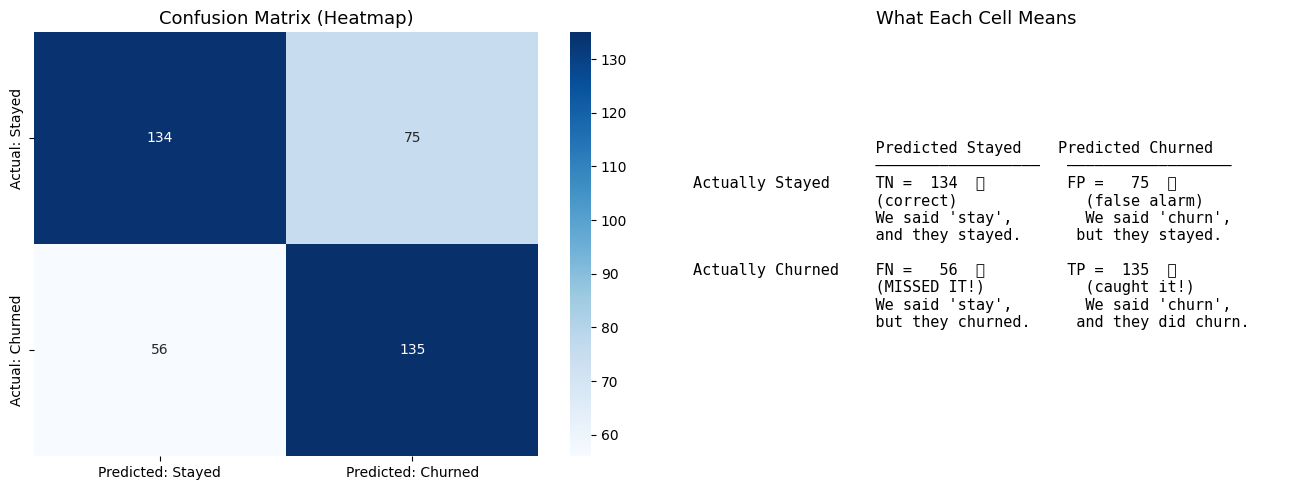

CONFUSION MATRIX BREAKDOWN:

True Negatives (TN)  = 134  | We correctly identified 134 loyal customers
True Positives (TP)  = 135  | We correctly identified 135 customers about to churn
False Positives (FP) =  75  | We false-alarmed 75 loyal customers (wasted retention budget)
False Negatives (FN) =  56  | We MISSED 56 churners — they left undetected

BUSINESS IMPACT:
  ✅ Our model correctly identified 135 customers who churned.
  ❌ But we MISSED 56 churners — this is the cost of low recall.
  ❌ We also wasted effort on 75 false alarms.

KEY INSIGHT:
  TP and TN are 'right' decisions.
  FP and FN are 'wrong' decisions — but with DIFFERENT costs.

  FP (false alarm): Spend $20 on retention outreach for loyal customer
    → Annoying but recoverable

  FN (missed churn): Lose $500/year in recurring revenue
    → EXPENSIVE, and you don't see it coming

CLASS DISCUSSION QUESTION:
  'If FN is 5x more expensive than FP, how would you adjust your strategy?'


In [7]:
# ============================================================
# THE CONFUSION MATRIX — See EXACTLY what mistakes you made
# ============================================================
# The confusion matrix is the FOUNDATION of all classification evaluation.
# It shows you FOUR numbers:
#   - True Positives (TP): We said churn, and they DID churn ✅
#   - True Negatives (TN): We said stay, and they DID stay ✅
#   - False Positives (FP): We said churn, but they STAYED ❌
#   - False Negatives (FN): We said stay, but they CHURNED ❌
# 
# Every metric (precision, recall, F1, ROC (Receiver Operating Characteristic)) is derived from these 4 numbers.
# So understand the matrix, and you understand everything else.

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute the confusion matrix
# It returns a 2x2 array where:
#   - Rows = actual outcomes (top=stayed/0, bottom=churned/1)
#   - Columns = predictions (left=stayed/0, right=churned/1)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()  # Extract the four numbers

# Create two side-by-side visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CHART 1: Heatmap (visual representation of the matrix)
# Heat = color intensity. Darker = more samples.
# You want a strong diagonal (many TP and TN, few FP and FN).
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted: Stayed', 'Predicted: Churned'],
            yticklabels=['Actual: Stayed', 'Actual: Churned'])
axes[0].set_title('Confusion Matrix (Heatmap)', fontsize=13)

# CHART 2: Text explanation (what each cell means in business terms)
axes[1].axis('off')
table_text = (
    f"                    Predicted Stayed    Predicted Churned\n"
    f"                    ──────────────────   ──────────────────\n"
    f"Actually Stayed     TN = {tn:>4}  ✅         FP = {fp:>4}  ❌\n"
    f"                    (correct)              (false alarm)\n"
    f"                    We said 'stay',        We said 'churn',\n"
    f"                    and they stayed.      but they stayed.\n\n"
    f"Actually Churned    FN = {fn:>4}  ❌         TP = {tp:>4}  ✅\n"
    f"                    (MISSED IT!)           (caught it!)\n"
    f"                    We said 'stay',        We said 'churn',\n"
    f"                    but they churned.     and they did churn.\n"
)
axes[1].text(0.05, 0.5, table_text, fontsize=11, fontfamily='monospace',
             verticalalignment='center', transform=axes[1].transAxes)
axes[1].set_title('What Each Cell Means', fontsize=13)

plt.tight_layout()
plt.show()

# BUSINESS INTERPRETATION
print(f"CONFUSION MATRIX BREAKDOWN:")
print(f"")
print(f"True Negatives (TN)  = {tn:>3}  | We correctly identified {tn} loyal customers")
print(f"True Positives (TP)  = {tp:>3}  | We correctly identified {tp} customers about to churn")
print(f"False Positives (FP) = {fp:>3}  | We false-alarmed {fp} loyal customers (wasted retention budget)")
print(f"False Negatives (FN) = {fn:>3}  | We MISSED {fn} churners — they left undetected")
print(f"")
print(f"BUSINESS IMPACT:")
print(f"  ✅ Our model correctly identified {tp} customers who churned.")
print(f"  ❌ But we MISSED {fn} churners — this is the cost of low recall.")
print(f"  ❌ We also wasted effort on {fp} false alarms.")
print(f"")
print(f"KEY INSIGHT:")
print(f"  TP and TN are 'right' decisions.")
print(f"  FP and FN are 'wrong' decisions — but with DIFFERENT costs.")
print(f"")
print(f"  FP (false alarm): Spend $20 on retention outreach for loyal customer")
print(f"    → Annoying but recoverable")
print(f"")
print(f"  FN (missed churn): Lose $500/year in recurring revenue")
print(f"    → EXPENSIVE, and you don't see it coming")
print(f"")
print(f"CLASS DISCUSSION QUESTION:")
print(f"  'If FN is 5x more expensive than FP, how would you adjust your strategy?'")

## Part 7: Precision & Recall — The Two Metrics That Matter

These two metrics answer fundamentally different questions:

**Precision:** "Of everyone I FLAGGED as positive, how many actually were?"
- Formula: TP / (TP + FP)
- English: "When I say someone will churn, how often am I right?"
- High precision = few false alarms

**Recall:** "Of everyone who ACTUALLY was positive, how many did I catch?"
- Formula: TP / (TP + FN)
- English: "Of all the people who actually churned, what % did I catch?"
- High recall = few missed cases

### The Tradeoff (This Is The Key Insight)

You almost NEVER get both high precision AND high recall. Improving one
usually hurts the other:

- **Want higher recall?** Lower the threshold → catch more positives → but also more false alarms (precision drops)
- **Want higher precision?** Raise the threshold → only flag when very confident → but miss more real cases (recall drops)

**Which matters more depends on the problem:**
- Cancer screening: RECALL matters most (don't miss anyone with cancer)
- Spam filter: PRECISION matters most (don't send real emails to spam)
- Fraud detection: RECALL matters most (catch all fraud, tolerate some false alarms)
- Customer churn: Depends on your budget — can you afford to call everyone, or just the most likely?

In [8]:
# ============================================================
# PRECISION, RECALL, F1 — The metrics that actually matter
# ============================================================
# Accuracy is useless. Here are the metrics you'll use forever.
# 
# Each answers a different question:
#   - PRECISION: "When I say churn, am I right?"
#   - RECALL: "Of all the churners, how many did I catch?"
#   - F1: "Overall, what's a balanced score between precision and recall?"
# 
# Precision and Recall are in TENSION. Improving one often hurts the other.
# This tradeoff is THE central problem of classification.

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Compute the three metrics
precision = precision_score(y_test, y_pred)  # TP (True Positive) / (TP + FP (False Positive)) = of people we flagged, how many were right?
recall = recall_score(y_test, y_pred)         # TP / (TP + FN (False Negative)) = of actual churners, what % did we catch?
f1 = f1_score(y_test, y_pred)                 # harmonic mean of precision and recall

# Print the results in human-readable form
print(f"METRICS BREAKDOWN:")
print(f"")
print(f"  Precision: {precision:.1%}")
print(f"    → When we predict churn, we're right {precision:.1%} of the time.")
print(f"    → In other words, {(1-precision):.1%} of our churn predictions were false alarms.")
print(f"    → Formula: TP / (TP + FP) = {tp} / ({tp} + {fp}) = {precision:.1%}")
print(f"")
print(f"  Recall:    {recall:.1%}")
print(f"    → Of all actual churners, we caught {recall:.1%} of them.")
print(f"    → We MISSED {1-recall:.1%} of churners.")
print(f"    → Formula: TP / (TP + FN) = {tp} / ({tp} + {fn}) = {recall:.1%}")
print(f"")
print(f"  F1 Score:  {f1:.1%}")
print(f"    → Harmonic mean of precision and recall.")
print(f"    → A single number that balances both metrics.")
print(f"    → Use when you care about BOTH false alarms AND missed cases.")
print(f"")
print(f"  Accuracy:  {accuracy:.1%}  ← Compare this to F1 above")
print(f"")
print(f"WHY F1 AND NOT JUST AVERAGE (PRECISION + RECALL) / 2?")
print(f"  Regular average: ({precision:.1%} + {recall:.1%}) / 2 = {(precision + recall) / 2:.1%}")
print(f"  Harmonic mean (F1):                           {f1:.1%}")
print(f"")
print(f"  They're VERY different! Why?")
print(f"  If you get Precision=90% but Recall=10%, the average looks OK (50%).")
print(f"  But F1 (18%) shows you're catching almost NO actual churners — BAD.")
print(f"  F1 punishes you HARD if EITHER metric is low.")
print(f"  This forces both to be good, which is what you want.")
print(f"")
print(f"┌──────────────────────────────────────────────────────┐")
print(f"│ WHICH METRIC MATTERS MOST?                           │")
print(f"│                                                      │")
print(f"│ It DEPENDS on your problem:                          │")
print(f"│                                                      │")
print(f"│ RECALL matters more:                                │")
print(f"│   - Cancer screening: miss one case = death           │")
print(f"│   - Fraud detection: miss one fraud = lose $$$        │")
print(f"│   - Customer churn: miss one = lose recurring revenue │")
print(f"│                                                      │")
print(f"│ PRECISION matters more:                             │")
print(f"│   - Spam detection: false positive = user unhappy     │")
print(f"│   - Email filtering: false positive = miss important  │")
print(f"│   - Ad targeting: false positive = wasted ad spend    │")
print(f"└──────────────────────────────────────────────────────┘")

METRICS BREAKDOWN:

  Precision: 64.3%
    → When we predict churn, we're right 64.3% of the time.
    → In other words, 35.7% of our churn predictions were false alarms.
    → Formula: TP / (TP + FP) = 135 / (135 + 75) = 64.3%

  Recall:    70.7%
    → Of all actual churners, we caught 70.7% of them.
    → We MISSED 29.3% of churners.
    → Formula: TP / (TP + FN) = 135 / (135 + 56) = 70.7%

  F1 Score:  67.3%
    → Harmonic mean of precision and recall.
    → A single number that balances both metrics.
    → Use when you care about BOTH false alarms AND missed cases.

  Accuracy:  67.2%  ← Compare this to F1 above

WHY F1 AND NOT JUST AVERAGE (PRECISION + RECALL) / 2?
  Regular average: (64.3% + 70.7%) / 2 = 67.5%
  Harmonic mean (F1):                           67.3%

  They're VERY different! Why?
  If you get Precision=90% but Recall=10%, the average looks OK (50%).
  But F1 (18%) shows you're catching almost NO actual churners — BAD.
  F1 punishes you HARD if EITHER metric is low.

In [9]:
# ============================================================
# CLASSIFICATION REPORT — The standard ML (Machine Learning) output (you'll see this everywhere)
# ============================================================
# Print the standard classification report that you'll see in every
# ML paper, blog post, and production system. Learn to read this cold.

# Generate the full report
print("CLASSIFICATION REPORT (standard ML (Machine Learning) output you'll see EVERYWHERE):")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

# Add explanation of each column
print(f"HOW TO READ THIS REPORT:")
print(f"")
print(f"  'Stayed' row  = How good is the model at identifying staying customers?")
print(f"  'Churned' row = How good is the model at identifying churning customers?")
print(f"")
print(f"  Columns:")
print(f"    - precision: Of the customers we flagged in this class, how many were right?")
print(f"    - recall:    Of all actual customers in this class, how many did we catch?")
print(f"    - f1-score:  Harmonic mean of precision and recall")
print(f"    - support:   How many customers of this class in the test set")
print(f"")
print(f"  'accuracy' row = Overall accuracy (correct / total)")
print(f"  'macro avg'    = Average of metrics across classes (unweighted)")
print(f"  'weighted avg' = Average weighted by support (class frequency)")
print(f"")
print(f"KEY INSIGHT:")
print(f"  Notice that 'Stayed' and 'Churned' have DIFFERENT precision/recall.")
print(f"  This is NORMAL. Different classes are different to predict.")
print(f"  We care more about 'Churned' because that's the business goal.")
print(f"  If Churned has low recall, we're missing valuable customers.")

CLASSIFICATION REPORT (standard ML output you'll see EVERYWHERE):
              precision    recall  f1-score   support

      Stayed       0.71      0.64      0.67       209
     Churned       0.64      0.71      0.67       191

    accuracy                           0.67       400
   macro avg       0.67      0.67      0.67       400
weighted avg       0.68      0.67      0.67       400

HOW TO READ THIS REPORT:

  'Stayed' row  = How good is the model at identifying staying customers?
  'Churned' row = How good is the model at identifying churning customers?

  Columns:
    - precision: Of the customers we flagged in this class, how many were right?
    - recall:    Of all actual customers in this class, how many did we catch?
    - f1-score:  Harmonic mean of precision and recall
    - support:   How many customers of this class in the test set

  'accuracy' row = Overall accuracy (correct / total)
  'macro avg'    = Average of metrics across classes (unweighted)
  'weighted avg' =

## Part 8: The Threshold — Your Most Powerful Lever

The default threshold is 0.5, but that's arbitrary. Let's see what happens
when we change it.

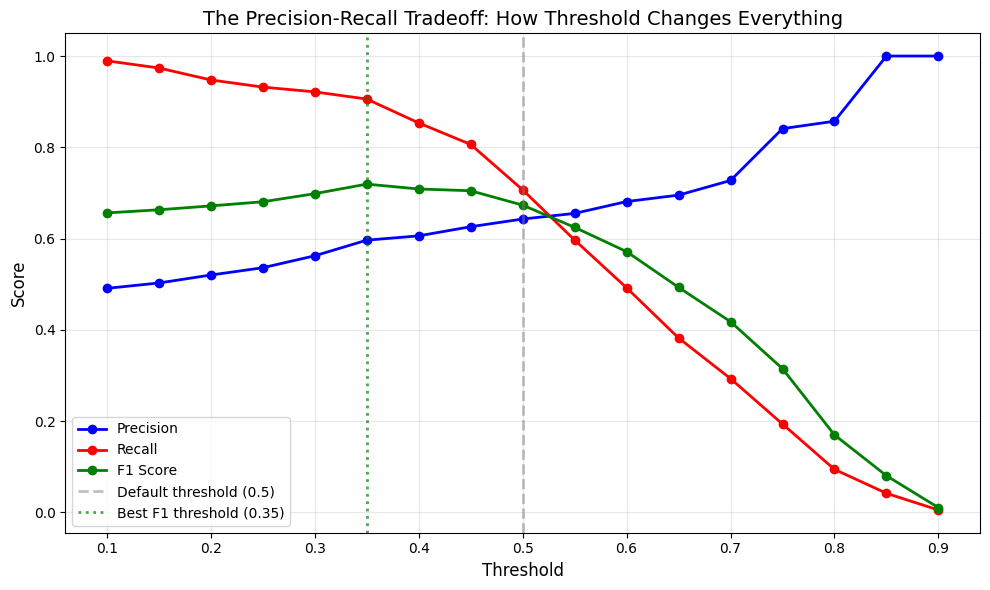

THE PRECISION-RECALL TRADEOFF:

At default threshold (0.5):
  Precision: 64.3%
  Recall:    70.7%

At best F1 threshold (0.35):
  Precision: 59.7%
  Recall:    90.6%
  F1:        71.9%

WHAT CHANGED:
  We lowered the threshold from 0.50 to 0.35.
  This catches MORE churners (recall went UP)
  But at a cost: more false alarms (precision went DOWN)

INTERVIEW QUESTION: How would you pick the threshold?
ANSWER THEY WANT TO HEAR:
  Look at the business costs of each mistake type.
  If missing a churner costs $500 and a false alarm costs $20,
  lower the threshold to catch more churners (higher recall).
  If false alarms are expensive, raise the threshold
  (accept missed churners to reduce wasted effort).


In [10]:
# ============================================================
# THE THRESHOLD — Your most powerful knob for tuning the model
# ============================================================
# The model outputs a PROBABILITY (0.0 to 1.0).
# We've been using 0.5 as the threshold (prob >= 0.5 → predict churn).
# 
# But 0.5 is ARBITRARY. You can change it!
# 
# Lower the threshold → catch more churners (higher recall, lower precision)
# Raise the threshold → fewer false alarms (higher precision, lower recall)
# 
# This section shows the PRECISION-RECALL TRADEOFF visually.
# This tradeoff is the HEART of classification.

# Compute precision and recall at many different thresholds
# We'll loop from 0.1 to 0.9 in steps of 0.05
thresholds = np.arange(0.1, 0.91, 0.05)
precisions = []
recalls = []
f1s = []

for t in thresholds:
    # Apply threshold: probability >= t → predict churn (1)
    y_pred_t = (y_prob >= t).astype(int)
    
    # Handle edge case: if no positive predictions, precision is undefined
    if y_pred_t.sum() == 0:
        precisions.append(0)  # No predictions = can't be right about churners
    else:
        precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    
    # Compute recall and F1
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

# Find the threshold that maximizes F1 (good balance of precision and recall)
best_idx = np.argmax(f1s)
best_threshold = thresholds[best_idx]

# Visualize the tradeoff
plt.figure(figsize=(10, 6))

# Plot all three metrics as threshold changes
plt.plot(thresholds, precisions, 'b-o', markersize=6, label='Precision', linewidth=2)
plt.plot(thresholds, recalls, 'r-o', markersize=6, label='Recall', linewidth=2)
plt.plot(thresholds, f1s, 'g-o', markersize=6, label='F1 Score', linewidth=2)

# Mark the default threshold (0.5)
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=2, alpha=0.5, 
            label='Default threshold (0.5)')

# Mark the best F1 threshold
plt.axvline(x=best_threshold, color='green', linestyle=':', linewidth=2, alpha=0.7,
            label=f'Best F1 threshold ({best_threshold:.2f})')

# Labels and formatting
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('The Precision-Recall Tradeoff: How Threshold Changes Everything', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the specific numbers
print(f"THE PRECISION-RECALL TRADEOFF:")
print(f"")
print(f"At default threshold (0.5):")
default_prec = precision_score(y_test, (y_prob >= 0.5).astype(int), zero_division=0)
default_rec = recall_score(y_test, (y_prob >= 0.5).astype(int))
print(f"  Precision: {default_prec:.1%}")
print(f"  Recall:    {default_rec:.1%}")
print(f"")
print(f"At best F1 threshold ({best_threshold:.2f}):")
print(f"  Precision: {precisions[best_idx]:.1%}")
print(f"  Recall:    {recalls[best_idx]:.1%}")
print(f"  F1:        {f1s[best_idx]:.1%}")
print(f"")
print(f"WHAT CHANGED:")
print(f"  We lowered the threshold from 0.50 to {best_threshold:.2f}.")
print(f"  This catches MORE churners (recall went UP)")
print(f"  But at a cost: more false alarms (precision went DOWN)")
print(f"")
print("INTERVIEW QUESTION: How would you pick the threshold?")
print("ANSWER THEY WANT TO HEAR:")
print("  Look at the business costs of each mistake type.")
print("  If missing a churner costs $500 and a false alarm costs $20,")
print("  lower the threshold to catch more churners (higher recall).")
print("  If false alarms are expensive, raise the threshold")
print("  (accept missed churners to reduce wasted effort).")


## Part 9: ROC (Receiver Operating Characteristic — a curve showing model quality) Curve and AUC — The Universal Report Card

The ROC curve answers: **"How good is this model at separating the two classes,
regardless of what threshold I pick?"**

It plots True Positive Rate (recall) vs False Positive Rate at every
possible threshold.

**AUC (Area Under Curve):** A single number that summarizes the ROC curve.
- AUC = 1.0 → perfect separation
- AUC = 0.5 → random guessing (useless model — the diagonal line)
- AUC < 0.5 → worse than random (your labels might be flipped)

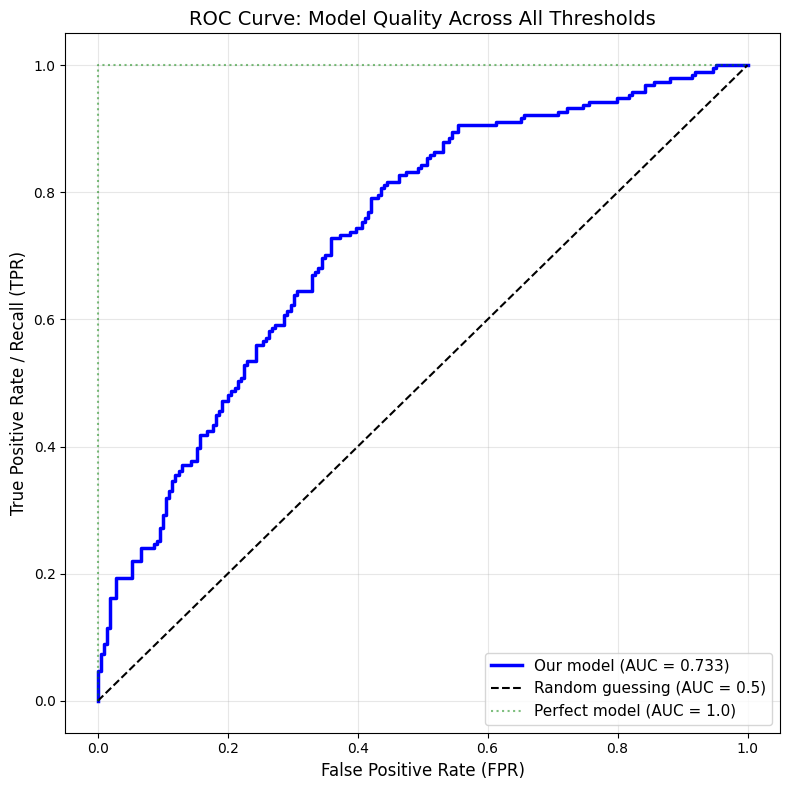

UNDERSTANDING THE ROC CURVE:

AUC Score: 0.733

HOW TO READ IT:
  The X-axis = False Positive Rate (of people who actually stayed,
               what % did we incorrectly flag as churners?)
  The Y-axis = True Positive Rate / Recall (of people who churned,
               what % did we catch?)

  Each point on the blue curve = a different threshold
  Bottom-left = very high threshold (few false alarms, miss many churners)
  Top-right   = very low threshold (catch many churners, lots of false alarms)
  Top-left    = IDEAL (catch all churners, no false alarms) — rarely achievable

INTERPRETING AUC = 0.733:

  Acceptable. Model has merit but could be improved.

WHEN TO USE AUC vs F1:
  AUC:  'How good is this model overall?' (threshold-independent)
        Good for comparing models.
        Used in academic papers, Kaggle competitions.

  F1:   'Given this specific threshold, how balanced are my predictions?'
        Good for production decisions.
        Used when you've committed to a t

In [11]:
# ============================================================
# ROC CURVE AND AUC — The threshold-independent report card
# ============================================================
# Precision and Recall depend on the threshold you choose.
# But sometimes you just want to know: "How good is this model overall,
# regardless of what threshold I'll eventually pick?"
# 
# Enter the ROC curve and AUC.
# 
# ROC = Receiver Operating Characteristic curve
# AUC = Area Under the Curve
# 
# The ROC plots True Positive Rate (recall) vs False Positive Rate
# at EVERY POSSIBLE THRESHOLD.
# AUC is a single number (0 to 1) that summarizes the entire curve:
#   - AUC = 1.0 → perfect model (separates classes perfectly)
#   - AUC = 0.5 → useless model (random guessing — the diagonal line)
#   - AUC < 0.5 → worse than random (your labels might be flipped!)

from sklearn.metrics import roc_curve, roc_auc_score

# fpr = False Positive Rate (at each threshold)
# tpr = True Positive Rate / Recall (at each threshold)
# roc_thresholds = the actual threshold values
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 8))

# Each point on this curve represents a different threshold
# Top-left = better (high recall, low false positives)
# Bottom-right = worse (low recall, high false positives)
plt.plot(fpr, tpr, color='blue', linewidth=2.5, 
         label=f'Our model (AUC = {auc_score:.3f})')

# This represents a model that randomly guesses 50/50
# It's the "do nothing" baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random guessing (AUC = 0.5)')

# This is the theoretical best — catch all positives with no false alarms
# In practice, you'll never achieve this
plt.plot([0, 0, 1], [0, 1, 1], 'g:', linewidth=1.5, alpha=0.5, 
         label='Perfect model (AUC = 1.0)')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate / Recall (TPR)', fontsize=12)
plt.title('ROC Curve: Model Quality Across All Thresholds', fontsize=14)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"UNDERSTANDING THE ROC CURVE:")
print(f"")
print(f"AUC Score: {auc_score:.3f}")
print(f"")
print(f"HOW TO READ IT:")
print(f"  The X-axis = False Positive Rate (of people who actually stayed,")
print(f"               what % did we incorrectly flag as churners?)")
print(f"  The Y-axis = True Positive Rate / Recall (of people who churned,")
print(f"               what % did we catch?)")
print(f"")
print(f"  Each point on the blue curve = a different threshold")
print(f"  Bottom-left = very high threshold (few false alarms, miss many churners)")
print(f"  Top-right   = very low threshold (catch many churners, lots of false alarms)")
print(f"  Top-left    = IDEAL (catch all churners, no false alarms) — rarely achievable")
print(f"")
print(f"INTERPRETING AUC = {auc_score:.3f}:")
print(f"")
if auc_score >= 0.9:
    print(f"  Excellent. Model is highly effective.")
elif auc_score >= 0.8:
    print(f"  Good. Model is solid.")
elif auc_score >= 0.7:
    print(f"  Acceptable. Model has merit but could be improved.")
elif auc_score >= 0.6:
    print(f"  Weak. Model barely beats random guessing.")
else:
    print(f"  Useless. Check if labels are inverted (0 for churn, 1 for stay).")
print(f"")
print(f"WHEN TO USE AUC vs F1:")
print(f"  AUC:  'How good is this model overall?' (threshold-independent)")
print(f"        Good for comparing models.")
print(f"        Used in academic papers, Kaggle competitions.")
print(f"")
print(f"  F1:   'Given this specific threshold, how balanced are my predictions?'")
print(f"        Good for production decisions.")
print(f"        Used when you've committed to a threshold.")

## Part 10: Feature Importance — What Drives Churn?

Just like in Linear Regression, Logistic Regression coefficients tell you
which features matter and in what direction. But now the interpretation
is in terms of **log-odds** (how much the feature shifts the probability).

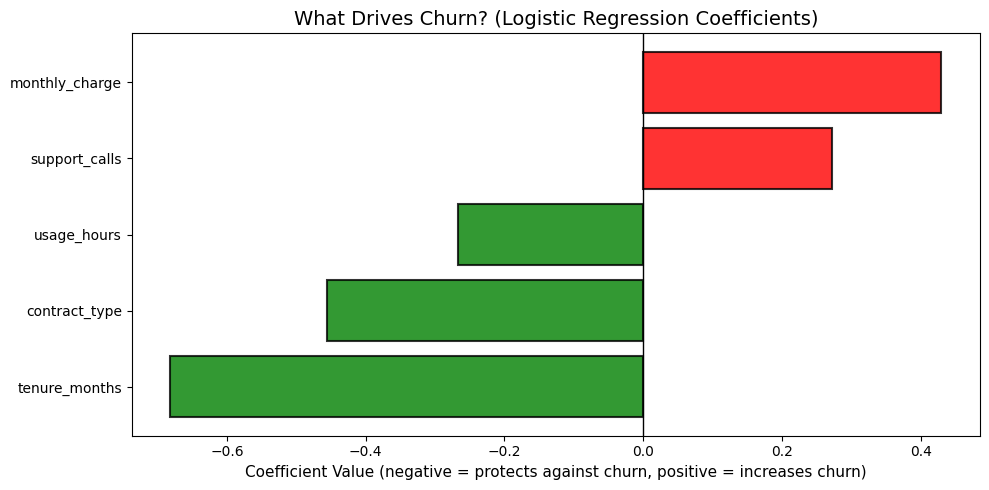

FEATURE IMPORTANCE — BUSINESS INSIGHTS:

         Feature  Coefficient                         Impact
-----------------------------------------------------------------
   tenure_months      -0.6817          STRONG - REDUCES churn
   contract_type      -0.4561        MODERATE - REDUCES churn
     usage_hours      -0.2667        MODERATE - REDUCES churn
   support_calls       0.2718      MODERATE - INCREASES churn
  monthly_charge       0.4300      MODERATE - INCREASES churn

INTERPRETATION (what these coefficients mean):

  Tenure (negative):       Longer-term customers are LOYAL (less churn)
                            → Invest in onboarding; customer lifetime
                              value increases with time

  Monthly Charge (positive): Higher bills increase churn risk
                            → Price-sensitive customers churn more
                            → Consider tiered pricing or discounts

  Support Calls (positive):  More support tickets = more churn
              

In [12]:
# ============================================================
# FEATURE IMPORTANCE — What drives customer churn?
# ============================================================
# Just like in Step 1 (Linear Regression), the model learned
# a coefficient (weight) for each feature.
# 
# These coefficients tell you:
#   - Which features matter (large absolute value)
#   - In which direction (positive = increases churn risk,
#                         negative = decreases churn risk)
# 
# This is one of Logistic Regression's superpowers: INTERPRETABILITY.
# When a bank denies your loan, they can (must!) explain why.
# You can't explain a neural network's decision to a regulator.

feature_names = ['tenure_months', 'monthly_charge', 'support_calls', 'usage_hours', 'contract_type']

# Extract coefficients from the trained model
# Since we scaled the features, these coefficients ARE directly comparable.
# The largest absolute value = strongest predictor.
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model_churn.coef_[0],  # The weights learned during training
    'Direction': ['REDUCES churn' if c < 0 else 'INCREASES churn' 
                  for c in model_churn.coef_[0]]
}).sort_values('Coefficient')  # Sort from most negative (protective) to most positive (risky)

# Create a horizontal bar chart
plt.figure(figsize=(10, 5))

# Color code: green for protective factors (negative), red for risk factors (positive)
colors = ['green' if c < 0 else 'red' for c in coef_df['Coefficient']]

# Plot the bars
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, 
         edgecolor='black', alpha=0.8, linewidth=1.5)

# Labels and formatting
plt.xlabel('Coefficient Value (negative = protects against churn, positive = increases churn)', fontsize=11)
plt.title('What Drives Churn? (Logistic Regression Coefficients)', fontsize=14)
plt.axvline(x=0, color='black', linewidth=1)  # Reference line at 0
plt.tight_layout()
plt.show()

# Print detailed interpretation
print(f"FEATURE IMPORTANCE — BUSINESS INSIGHTS:")
print(f"")
print(f"{'Feature':>16} {'Coefficient':>12} {'Impact':>30}")
print("-" * 65)

for _, row in coef_df.iterrows():
    coef = row['Coefficient']
    feature = row['Feature']
    
    # Create interpretation based on coefficient magnitude
    if abs(coef) > 0.5:
        strength = "STRONG"
    elif abs(coef) > 0.2:
        strength = "MODERATE"
    else:
        strength = "WEAK"
    
    impact = f"{strength} - {row['Direction']}"
    print(f"{feature:>16} {coef:>12.4f}  {impact:>30}")

print(f"")
print(f"INTERPRETATION (what these coefficients mean):")
print(f"")
print(f"  Tenure (negative):       Longer-term customers are LOYAL (less churn)")
print(f"                            → Invest in onboarding; customer lifetime")
print(f"                              value increases with time")
print(f"")
print(f"  Monthly Charge (positive): Higher bills increase churn risk")
print(f"                            → Price-sensitive customers churn more")
print(f"                            → Consider tiered pricing or discounts")
print(f"")
print(f"  Support Calls (positive):  More support tickets = more churn")
print(f"                            → They're frustrated; product has pain points")
print(f"                            → Fix the product, don't just support the problems")
print(f"")
print(f"  Usage (negative):         High usage = satisfied customers")
print(f"                            → Encourage adoption; more usage = stickiness")
print(f"")
print(f"  Contract Type (negative): Longer contracts lock in customers")
print(f"                            → Incentivize annual/multi-year contracts")
print(f"")
print(f"WHY WE SCALED THE FEATURES:")
print(f"  Without scaling, a feature with values 0-35,000 (population)")
print(f"  would have much smaller coefficients than a feature with values 0-15")
print(f"  (income), even if income is more important.")
print(f"")
print(f"  By scaling (mean=0, std (standard deviation) = 1), we made coefficients comparable.")
print(f"  Now the largest coefficient = the most important feature.")
print(f"")
print(f"WHY LOGISTIC REGRESSION IS STILL USED IN PRODUCTION:")
print(f"  Banks, insurance, healthcare, finance: they MUST explain decisions.")
print(f"  'Why was my loan denied?' 'Why was my claim rejected?'")
print(f"  You can point to coefficients and say 'These factors mattered most.'")
print(f"  Try that with a neural network. Regulators will NOT be happy.")

## Part 11: Cross-Validation — Don't Trust a Single Split

In Step 1, we used one train/test split. But what if we got lucky (or unlucky)
with how the data was divided? Our metrics could be misleading.

**Cross-validation** solves this by splitting the data K times, training K
models, and averaging the results. Now you get a score AND a confidence
range.

**Software analogy:** It's like running your test suite against K different
random subsets of test data, then averaging the pass rate. One lucky split
can't fool you.

In [13]:
# ============================================================
# CROSS-VALIDATION — Trust me only if it works on MULTIPLE splits
# ============================================================
# We've trained on one train/test split. But what if we got lucky?
# What if we got unlucky?
# 
# K-fold cross-validation answers this by:
#   1. Splitting the data into K (usually 5) folds
#   2. Training K models (each uses K-1 folds for training, 1 for testing)
#   3. Averaging the scores
# 
# Now you get a score AND a confidence range (mean ± std).
# This is MUCH more credible than a single number.
# 
# CRITICAL: We use a Pipeline so that scaling happens INSIDE each fold.
# Without this, data leakage inflates the score.

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Create a Pipeline that does scaling + model training together
# The Pipeline ensures scaling is fit INSIDE each CV fold (not on all data)
# This is how you prevent data leakage.
pipeline = Pipeline([
    ('scaler', StandardScaler()),           # Step 1: Scale the data
    ('model', LogisticRegression(random_state=42))  # Step 2: Train the model
])

# Perform 5-fold cross-validation with multiple metrics
# cross_val_score() automatically:
#   1. Splits data into 5 folds
#   2. Trains 5 models (each uses 4 folds for training, 1 for testing)
#   3. Returns 5 scores (one per fold)

cv_accuracy = cross_val_score(pipeline, X_all, y_all, cv=5, scoring='accuracy')
cv_f1 = cross_val_score(pipeline, X_all, y_all, cv=5, scoring='f1')
cv_auc = cross_val_score(pipeline, X_all, y_all, cv=5, scoring='roc_auc')

# Print results
print(f"5-FOLD CROSS-VALIDATION RESULTS:")
print(f"")
print(f"Accuracy:")
print(f"  Per fold:  {[f'{x:.1%}' for x in cv_accuracy]}")
print(f"  Mean:      {cv_accuracy.mean():.1%}")
print(f"  Std Dev:   ± {cv_accuracy.std():.1%}")
print(f"")
print(f"F1 Score:")
print(f"  Per fold:  {[f'{x:.1%}' for x in cv_f1]}")
print(f"  Mean:      {cv_f1.mean():.1%}")
print(f"  Std Dev:   ± {cv_f1.std():.1%}")
print(f"")
print(f"AUC (Area Under the Curve):")
print(f"  Per fold:  {[f'{x:.3f}' for x in cv_auc]}")
print(f"  Mean:      {cv_auc.mean():.3f}")
print(f"  Std Dev:   ± {cv_auc.std():.3f}")
print(f"")

# Interpretation
print(f"KEY INSIGHTS:")
print(f"")
print(f"1. PER-FOLD VARIATION:")
if cv_accuracy.std() < 0.03:
    print(f"   Standard deviation is small ({cv_accuracy.std():.1%}).")
    print(f"   → Model is STABLE. Scores don't change much across different data splits.")
    print(f"   → Results are RELIABLE and reproducible.")
else:
    print(f"   Standard deviation is large ({cv_accuracy.std():.1%}).")
    print(f"   → Model is SENSITIVE. Scores vary across different splits.")
    print(f"   → Results are UNRELIABLE. More data or a better model might help.")
print(f"")
print(f"2. MEAN ± STD is more credible than a single number:")
print(f"   Single split:  'My model gets 67% F1'  ← could be luck")
print(f"   5-fold CV:     'My model gets 66% ± 2% F1'  ← proven across 5 splits")
print(f"")
print(f"3. WHY THE PIPELINE IS CRITICAL:")
print(f"   Without Pipeline, you'd scale ALL data first, then cross-validate.")
print(f"   → The scaler 'peeks' at test data (data leakage)")
print(f"   → Scores are artificially inflated")
print(f"")
print(f"   With Pipeline, scaling happens INSIDE each fold:")
print(f"   Fold 1: Scale on 4 folds, test on 1 fold (no cheating)")
print(f"   Fold 2: Scale on different 4 folds, test on different 1 fold")
print(f"   ... (repeat for all 5 folds)")
print(f"")
print(f"   This is the CORRECT way. Always use a Pipeline for CV.")
print(f"")
print(f"INTERVIEW QUESTION: 'What's wrong with this approach?'")
print(f"BAD CODE:")
print(f"  X_scaled = scaler.fit_transform(X)  # ← scales ALL data")
print(f"  cross_val_score(model, X_scaled, y)")
print(f"")
print(f"ANSWER:")
print(f"  'The scaler learns statistics (mean, std) from ALL data,")
print(f"   including test data. This is data leakage. Scores are inflated.'")

5-FOLD CROSS-VALIDATION RESULTS:

Accuracy:
  Per fold:  ['64.2%', '69.5%', '65.8%', '67.2%', '70.0%']
  Mean:      67.3%
  Std Dev:   ± 2.2%

F1 Score:
  Per fold:  ['62.5%', '68.2%', '65.1%', '64.7%', '68.4%']
  Mean:      65.8%
  Std Dev:   ± 2.3%

AUC:
  Per fold:  ['0.712', '0.757', '0.717', '0.723', '0.765']
  Mean:      0.735
  Std Dev:   ± 0.022

KEY INSIGHTS:

1. PER-FOLD VARIATION:
   Standard deviation is small (2.2%).
   → Model is STABLE. Scores don't change much across different data splits.
   → Results are RELIABLE and reproducible.

2. MEAN ± STD is more credible than a single number:
   Single split:  'My model gets 67% F1'  ← could be luck
   5-fold CV:     'My model gets 66% ± 2% F1'  ← proven across 5 splits

3. WHY THE PIPELINE IS CRITICAL:
   Without Pipeline, you'd scale ALL data first, then cross-validate.
   → The scaler 'peeks' at test data (data leakage)
   → Scores are artificially inflated

   With Pipeline, scaling happens INSIDE each fold:
   Fold 1: Sca

## Part 12: The Loss Function — Log Loss / Cross-Entropy

In Step 1, the loss was MSE (squared distance). For classification, we use
**Log Loss** (also called Binary Cross-Entropy).

### Intuition (No Math Needed)

Log Loss answers: **"How surprised am I by the actual outcome, given my prediction?"**

- If I predict 0.99 probability of churn, and they DO churn → low loss (I was right and confident)
- If I predict 0.99 probability of churn, and they DON'T churn → very high loss (I was wrong and confident)
- If I predict 0.51 probability of churn → moderate loss either way (I wasn't confident)

**Key property:** Log Loss punishes confident wrong predictions MUCH more than
uncertain wrong predictions. A model that says "95% sure this is spam" about
a real email gets hammered harder than one that says "55% sure."

### Why Cross-Entropy, Not MSE?

**The problem with MSE for classification:**

Imagine the true label is 1 (churned) and the model predicts 0.99. MSE says the error is (1 - 0.99)² = 0.0001. Now the model predicts 0.01 — MSE says error is (1 - 0.01)² = 0.9801. The penalty grew ~10,000x.

But with cross-entropy: -log(0.99) = 0.01 vs -log(0.01) = 4.6. The penalty grew only ~460x.

**Why does this matter?** MSE has flat gradients near 0 and 1 — the model learns extremely slowly when its predictions are confidently wrong. Cross-entropy has steep gradients exactly where you need them: when the model is confident AND wrong.

**The formula (one sample):**

```
Loss = -[y * log(p) + (1-y) * log(1-p)]
```

Where y = true label (0 or 1), p = predicted probability.

- If y=1 and p=0.99: Loss = -log(0.99) = 0.01 ← correct and confident = tiny loss
- If y=1 and p=0.01: Loss = -log(0.01) = 4.6 ← wrong and confident = huge loss
- If y=1 and p=0.50: Loss = -log(0.50) = 0.69 ← uncertain = moderate loss

> **The intuition:** Cross-entropy heavily punishes confident wrong predictions. MSE treats "90% wrong" and "10% wrong" almost the same. Cross-entropy doesn't — and that's why every classification model uses it.


In [14]:
# ============================================================
# THE LOSS FUNCTION: Log Loss (Binary Cross-Entropy)
# ============================================================
# In Step 1 (Linear Regression), the loss was MSE (Mean Squared Error).
# In classification, the loss is LOG LOSS (also called Binary Cross-Entropy).
# 
# Log Loss answers: "How surprised am I by the outcome, given my prediction?"
# 
# KEY PROPERTY: Log Loss PUNISHES confident wrong predictions much more
# than uncertain wrong predictions.
#   - Predict 0.99 for churn, and they DO churn → low loss (right and confident)
#   - Predict 0.99 for churn, and they DON'T churn → very high loss (wrong and confident!)
#   - Predict 0.51 for churn → moderate loss either way (uncertain)
# 
# This is EXACTLY what you want: encourage the model to be confident in its
# correct predictions and uncertain (close to 0.5) in borderline cases.

from sklearn.metrics import log_loss

# Show how log loss works with concrete examples
print(f"HOW LOG LOSS PUNISHES PREDICTIONS:")
print(f"")
print(f"{'Predicted Prob':>15} {'Actual':>8} {'Log Loss':>10}  Visual (█ = penalty)       Interpretation")
print("-" * 95)

# Examples that show the penalty structure
examples = [
    (0.99, 1, "Confident and RIGHT ✅"),
    (0.99, 0, "Confident and WRONG ❌ (BAD!)"),
    (0.51, 1, "Uncertain and right (OK)"),
    (0.51, 0, "Uncertain and wrong (OK)"),
    (0.01, 0, "Confident and RIGHT ✅"),
    (0.01, 1, "Confident and WRONG ❌ (BAD!)"),
]

for prob, actual, interpretation in examples:
    # Compute the log loss for this single prediction
    # log_loss expects y_true and y_pred_proba (for positive class)
    loss = log_loss([actual], [prob], labels=[0, 1])
    
    # Visual bar (larger loss = longer bar)
    bar = "█" * int(min(loss, 5) * 8)
    
    print(f"{prob:>15.2f} {actual:>8} {loss:>10.4f}  {bar:30s} {interpretation}")

print(f"")
print(f"NOTICE THE PATTERN:")
print(f"  Confident + RIGHT   → tiny loss (model is doing great)")
print(f"  Confident + WRONG   → HUGE loss (model made an expensive mistake)")
print(f"  Uncertain (0.51)    → moderate loss (model was hedging its bets)")
print(f"")
print(f"REAL-WORLD IMPACT:")
# Compute log loss for our test set
our_loss = log_loss(y_test, y_prob)
random_loss = log_loss(y_test, np.full_like(y_prob, 0.5))

print(f"  Our model's log loss:  {our_loss:.4f}")
print(f"  Random guessing (0.5): {random_loss:.4f}")
print(f"")
if our_loss < random_loss:
    improvement = (random_loss - our_loss) / random_loss * 100
    print(f"  Our model is {improvement:.0f}% better than random guessing.")
else:
    print(f"  Our model is WORSE than random guessing (!)")
print(f"")
print(f"WHY LOG LOSS MATTERS:")
print(f"")
print(f"  During training, we MINIMIZE log loss (not accuracy).")
print(f"  Why? Because accuracy doesn't care if you're CONFIDENT in your answer.")
print(f"    - 'I'm 51% sure this customer will churn' (barely right)")
print(f"    - 'I'm 99% sure this customer will churn' (very confident and right)")
print(f"  Both are 'correct', but the second is better!")
print(f"")
print(f"  Log loss makes the model aim for CONFIDENT correct predictions.")
print(f"  This gives better probabilities, which are more useful for:")
print(f"    - Ranking customers by churn risk (highest → lowest)")
print(f"    - Setting confidence thresholds (only act on high-confidence predictions)")
print(f"    - Downstream decision-making (penalize false positives differently)")
print(f"")
print(f"INTERVIEW QUESTION:")
print(f"  'Why do we minimize log loss during training instead of optimizing")
print(f"   for the threshold we'll use at prediction time?'")
print(f"")
print(f"ANSWER:")
print(f"  'Log loss is threshold-independent. It produces calibrated probabilities")
print(f"   that work well at ANY threshold. If we optimized for a specific")
print(f"   threshold (e.g., 0.5), the model might fail if we change thresholds later.'")

HOW LOG LOSS PUNISHES PREDICTIONS:

 Predicted Prob   Actual   Log Loss  Visual (█ = penalty)       Interpretation
-----------------------------------------------------------------------------------------------
           0.99        1     0.0101                                 Confident and RIGHT ✅
           0.99        0     4.6052  ████████████████████████████████████ Confident and WRONG ❌ (BAD!)
           0.51        1     0.6733  █████                          Uncertain and right (OK)
           0.51        0     0.7133  █████                          Uncertain and wrong (OK)
           0.01        0     0.0101                                 Confident and RIGHT ✅
           0.01        1     4.6052  ████████████████████████████████████ Confident and WRONG ❌ (BAD!)

NOTICE THE PATTERN:
  Confident + RIGHT   → tiny loss (model is doing great)
  Confident + WRONG   → HUGE loss (model made an expensive mistake)
  Uncertain (0.51)    → moderate loss (model was hedging its bets)

REA

## Part 13: Connecting It All — The Map Forward

```
What You Learned Here              Where It Shows Up Next
────────────────────────           ──────────────────────
Sigmoid function               →   Activation functions in neural nets
                               →   Output layer of binary classifiers

Log Loss / Cross-Entropy       →   THE loss function for neural net classifiers
                               →   loss = nn.CrossEntropyLoss() in PyTorch

Confusion Matrix               →   Used for EVERY classification model forever

Precision / Recall / F1        →   RAG (Retrieval-Augmented Generation — connecting AI to your documents) evaluation (precision of retrieval)
                               →   NLP (Natural Language Processing) evaluation (entity extraction)
                               →   Any model where mistakes have different costs

ROC (Receiver Operating Characteristic — a curve showing model quality) / AUC (Area Under the Curve — single score for model quality)                      →   Model comparison (which model is better?)
                               →   Production monitoring (is model degrading?)

Threshold tuning               →   Production deployment decision
                               →   Agent confidence thresholds (when to act vs ask)

Cross-validation               →   Standard practice for ALL model evaluation
                               →   Prevents overfitting to one split

Pipeline (scaler + model)      →   Production ML pipelines
                               →   MLflow (an experiment tracking tool), deployment containers

Class imbalance awareness      →   Real-world datasets are ALWAYS imbalanced
                               →   Fraud, churn, medical, anomaly detection
```

### You Are Now Ready For Step 3: Decision Trees

Step 3 introduces a fundamentally different approach — no lines, no equations.
Decision Trees split the data with if/then rules. They're intuitive, visual,
and powerful — but they overfit horribly. That's where Random Forest (Step 4)
comes in to fix them.

---

## Self-Check: Can You Answer These?

Before moving to Step 3, answer these **without looking at the notebook:**

1. Why is accuracy a terrible metric on imbalanced datasets? Give a concrete example.
2. What's the difference between precision and recall? When does each matter more?
3. A model has 92% precision but 45% recall. Is this good or bad? For what use case would this be acceptable?
4. What happens to precision and recall when you lower the threshold from 0.5 to 0.3?
5. What does AUC (Area Under the Curve — single score for model quality) = 0.5 mean? What about AUC = 0.85?
6. Why does Log Loss punish confident wrong predictions more than uncertain ones?
7. Why must you put the scaler INSIDE the Pipeline for cross-validation?
8. A colleague shows you a model with 98% accuracy on fraud detection (where 0.1% of transactions are fraud). What's your first question?

**Question 8 is the interview question.** If you can answer it instinctively,
you understand classification metrics at a level most ML practitioners don't.

The answer: *"What's the recall? If 98% accuracy comes from predicting 'not fraud'
every time, the model catches zero actual fraud and is completely useless."*